# Lecture 3. Bifurcations

## S32 Chaos, Random Processes, and Predictability

Any questions or comments to *hannah.christensen@physics.ox.ac.uk*

Book of the course: Nonlinear Dynamics and Chaos, by Steven Strogatz

$\bullet$ Although the dynamics of one-dimensional systems is very limited (all solutions either settle down to a steady equilibrium or head off to $\pm \infty$) they can have an interesting dependence on parameters.

$\bullet$ The qualitative structure of the flow can change as parameters are varied.

$\bullet$ These qualitative changes in the dynamics are called bifurcations and the parameter values at which they occur are called bifurcation points.


Bifurcations provide models of transitions and instabilities as some control parameter is varied e.g. a buckling beam

<div>
<img src="figures/fig3_0_1.png" width="400"/>
</div>

## 3.1 Saddle-Node Bifurcation

This is the basic mechanism by which fixed points are created and destroyed (as some parameter is varied)

e.g. consider $\dot{x} = r + x^2$

<div>
<img src="figures/fig3_1_1.png" width="800"/>
</div>

$\Rightarrow$ Bifurcation occurs at $r = 0$


A *bifurcation diagram* shows the fixed points and their stability as a function of the control parameter(s).

#### Example

Draw the bifucation diagram for $\dot{x} = r + x^2$

In [1]:
# TASK: Vary r and sketch out the bifurcation diagram

import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from sympy.solvers import solve, check_assumptions
from sympy import Symbol, I


# User set a list of r values here
r = [-2, -1.5, -1, -0.5, 0, 1, 2] #etc
# Consider using the arange function instead to choose many r values:
#r = np.arange(-2,2,1)

roots = []
r_vals = []    
derivativelist = []
x = Symbol('x')    

In [2]:
for t in range (0, len(r)):

    xdot = r[t] + x**2
    roots_t = solve(xdot,x)
    
    derivative = sym.diff(xdot)
    
    #only keep root if real
    for i in range (0, len(roots_t)):
        if check_assumptions(roots_t[i], real=True):
            roots = np.append(roots, roots_t[i])
            r_vals = np.append(r_vals, r[t])
            derivativelist = np.append(derivativelist, derivative.evalf(subs={x: roots_t[i]}))

In [3]:
stableroots = []
unstableroots = []
semistableroots = []
rstableroots = []
runstableroots = []
rsemistableroots = []
    
for i in range (0, len(derivativelist)): #this code produces 3 lists, one with stable roots, one unstable and one semi-stable
    if not np.iscomplex(derivativelist[i]):
        if derivativelist[i] <= 0:
            stableroots = np.append(stableroots, roots[i])
            rstableroots = np.append(rstableroots, r_vals[i])
        if derivativelist[i] >= 0:
            unstableroots = np.append(unstableroots, roots[i])
            runstableroots = np.append(runstableroots, r_vals[i])
        if derivativelist[i] == 0:
            semistableroots = np.append(semistableroots, roots[i])
            rsemistableroots = np.append(rsemistableroots, r_vals[i])



(-2.0, 2.0)

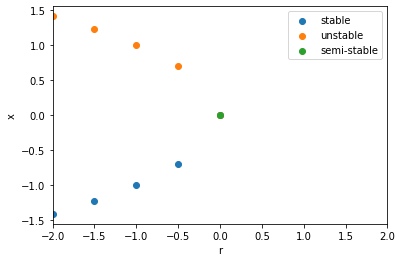

In [4]:
plt.scatter(rstableroots, stableroots)
plt.scatter(runstableroots, unstableroots)
plt.scatter(rsemistableroots, semistableroots)
plt.xlabel('r')
plt.ylabel('x')
plt.legend(['stable','unstable','semi-stable'])
plt.xlim(r[0],r[len(r)-1])

#### Answer

2. The bifurcation diagram is the continuous version of the figure produced by the above script

<div>
<img src="figures/Fig3_1_3.png" width="800"/>
</div>



The bifurcation diagram is a sketch of the fixed points as a function of a control parameter.

In contrast, the script below plots $x(t)$ for a given $r$. Make sure you are happy with the relation between these two plots.

Text(0, 0.5, 'x')

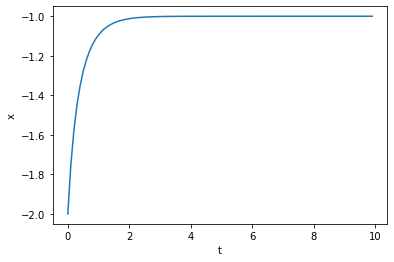

In [5]:
# TASK: Set x0 and r to convince yourself of the relationship between x(t) and the above bifurcation diagram
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def flow(x, t):
    dxdt = r + x**2
    return dxdt

# user to select initial value x0 and control parameter r here
x0 = -2
r  = -1

t = np.arange(0,10,0.1)
x = odeint(flow, x0, t)
plt.plot(t, x)
plt.xlabel('t')
plt.ylabel('x')

#### Warning about terminology

Bifurcation theory is full of conflicting terminology! The Saddle-node bifurcation is sometimes called the “fold” bifurcation, “turning point” bifurcation or “blue-sky” bifurcation (e.g. see Thompson & Stewart 2002).

#### Example

Conside the dynamical system $\dot{x} = r - x^2$

a) Find the fixed points

b) Use linear stability analysis to find their stability


$\bullet$ Fixed points $f(x) = r - x^2 = 0 \Rightarrow x^* = \pm \sqrt{r}$, Hence there are *two* fixed points for $r > 0$ but *none* for $r < 0$

$\bullet$   $ f'(x^*) = -2 x^* \Rightarrow x^* = \left\{ {\begin{array}{cc}
+\sqrt{r}: &  stable  \\ 
-\sqrt{r}: & unstable 
\end{array}} \right. $

$\bullet$  At bifurcation points $r = 0, f'(x^*) = 0$, hence linearization vanishes when the fixed points coalesce. Need to use an alternative approach to deduce the stability



#### Saddle node bifurcation in the real world?

$\bullet$ Mass and density of stars



<div>
<img src="figures/3_stars.pdf" width="800"/>
</div>

## 3.2 Transcritical Bifurcation

This is the basic mechanism by which fixed points change stability as some parameter is varied

#### Example

Draw the bifurcation diagram for $\dot{x} = rx - x^2$ (cf population growth)


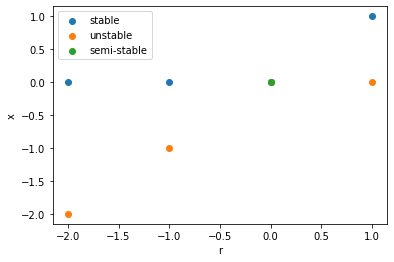

In [6]:
# TASK: Vary r and sketch out the bifurcation diagram

import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from sympy.solvers import solve, check_assumptions
from sympy import Symbol, I

# User set a list of r values here
r = np.arange(-2,2,1)

roots = []
r_vals = []    
derivativelist = []
x = Symbol('x')

for t in range (0, len(r)):

    xdot = r[t]*x - x**2
    roots_t = solve(xdot,x)
    
    derivative = sym.diff(xdot)
    
    #only keep root if real
    for i in range (0, len(roots_t)):
        if check_assumptions(roots_t[i], real=True):
            roots = np.append(roots, roots_t[i])
            r_vals = np.append(r_vals, r[t])
            derivativelist = np.append(derivativelist, derivative.evalf(subs={x: roots_t[i]}))
    
stableroots = []
unstableroots = []
semistableroots = []
rstableroots = []
runstableroots = []
rsemistableroots = []
    
for i in range (0, len(derivativelist)): #this code produces 3 lists, one with stable roots, one unstable and one semi-stable
    if not np.iscomplex(derivativelist[i]):
        if derivativelist[i] <= 0:
            stableroots = np.append(stableroots, roots[i])
            rstableroots = np.append(rstableroots, r_vals[i])
        if derivativelist[i] >= 0:
            unstableroots = np.append(unstableroots, roots[i])
            runstableroots = np.append(runstableroots, r_vals[i])
        if derivativelist[i] == 0:
            semistableroots = np.append(semistableroots, roots[i])
            rsemistableroots = np.append(rsemistableroots, r_vals[i])

plt.scatter(rstableroots, stableroots)
plt.scatter(runstableroots, unstableroots)
plt.scatter(rsemistableroots, semistableroots)
plt.xlabel('r')
plt.ylabel('x')
plt.legend(['stable','unstable','semi-stable'])

#### Answer

<div>
<img src="figures/fig3_2_1.png" width="600"/>
</div>

“Exchange of stabilities” between $x^* = 0$ and $x^* = r$. NB unlike saddle-node case, the two fixed points don’t disappear.

<div>
<img src="figures/fig3_2_2.png" width="400"/>
</div>

Transcritical bifurcation occurs when

$$ f(x^*) = f^{\prime}(x) = 0 $$

#### Example

Show that the following system undergoes a transcritical bifurcation:

$\dot{x} = x(1 - x^2) - a(1 - e^{-bx})$

By inspection $x^* = 0$ is a fixed point for all $(a,b)$. 

Expand around $x = 0$

$\dot{x} = (1 - ab)x + \frac{ab^2}{2} x^2 + O(x^3)$

Hence, transcritical bifurcation occurs when $ab = 1$. 

The *bifurcation curve* is the curve in parameter space which marks out the bifurcations

<div>
<img src="figures/fig3_2_3.png" width="400"/>
</div>


#### Transcritical bifurcation in the real world?

$\bullet$ Laser threshold (see Strogatz section 3.3).

$$ \dot{n} = gain - loss = GnN - kn $$

$GnN \sim$ stimulated emission; $kn \sim$ losses through endfaces; $N(t)$ is the number of excited atoms; $g > 0$ is the gain coefficient.

<div>
<img src="figures/2_laser.png" width="500"/>
</div>



Also

$ N(t) = N_0 - \alpha n $

(where $N_0$ depends on pump strength) since $N$ decreases by emission of photons $(\alpha > 0)$.
Hence $\dot{n} = (G N_0 - k) n - (\alpha G) n^2$


<div>
<img src="figures/fig3_3_2.png" width="800"/>
</div>



<div>
<img src="figures/fig3_3_3.png" width="400"/>
</div>


## 3.3 Pitchfork Bifurcation

This bifurcation is common in problems that have a symmetry, e.g. the buckling beam, and involves fixed points appearing and disappearing in symmetrical pairs.

#### (i) Supercritical Pitchfork Bifurcation

$ $e.g. $\dot{x} = rx - x^3$

<div>
<img src="figures/Fig3_4_1.png" width="600"/>
</div>

The bifurcation diagram is therefore:

<div>
<img src="figures/Fig3_4_2.png" width="400"/>
</div>

... hence the term "pitchfork"

#### Critical slowing down


$\bullet$ $r < 0$: Solutions decay exponentially fast

$\bullet$ $r = 0$: Linearization vanishes! Solutions decay algebraically fast $\Rightarrow$ "critical slowing down"
    
This leads to an increasingly slow recovery from perturbations, and is characteristic of many bifurcations. We can characterise this behaviour through assessing the temporal autocorrelation of the system. It can act as a useful early-warning of an approaching tipping point.


#### Supercritical pitchfork bifurcation in the real world?

$\bullet$ Rayleigh Benard Convection

<div>
<img src="figures/2_RBC.png" width="800"/>
</div>


#### Supercritical pitchfork bifurcation in the real world?

$\bullet$ Buckling beam


<div>
<img src="figures/2_bucklingbeam.png" width="800"/>
</div>

#### Supercritical pitchfork bifurcation in the real world?

<div>
<img src="figures/2_floatingbeam.png" width="800"/>
</div>

#### (ii) Subcritical Pitchfork Bifurcation

$ $e.g. $\dot{x} = rx + x^3$ - cubic term now *destabilizes* the system

![](figures/fig3_4_5.png)

$\bullet$ Non-zero fixed points are unstable and exist only below the bifurcation ($r < 0$) - cf "pitchfork" figure


#### Example

$ $In real physical systems, higher order terms are likely to be present....e.g. $\dot{x} = rx + x^3 - x^5$

Sketch the bifurcation diagram for this system


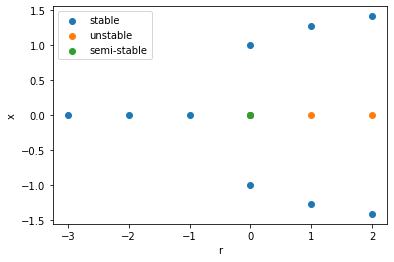

In [7]:
# TASK: Vary r and sketch out the bifurcation diagram

import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from sympy.solvers import solve, check_assumptions
from sympy import Symbol, I

# User set a list of r values here
r = np.arange(-3,3,1)

roots = []
r_vals = []    
derivativelist = []
x = Symbol('x')

for t in range (0, len(r)):

    xdot = r[t]*x + x**3 - x**5
    roots_t = solve(xdot,x)
    
    derivative = sym.diff(xdot)
    
    #only keep root if real
    for i in range (0, len(roots_t)):
        if check_assumptions(roots_t[i], real=True):
            roots = np.append(roots, roots_t[i])
            r_vals = np.append(r_vals, r[t])
            derivativelist = np.append(derivativelist, derivative.evalf(subs={x: roots_t[i]}))
    
stableroots = []
unstableroots = []
semistableroots = []
rstableroots = []
runstableroots = []
rsemistableroots = []
    
for i in range (0, len(derivativelist)): #this code produces 3 lists, one with stable roots, one unstable and one semi-stable
    if not np.iscomplex(derivativelist[i]):
        if derivativelist[i] <= 0:
            stableroots = np.append(stableroots, roots[i])
            rstableroots = np.append(rstableroots, r_vals[i])
        if derivativelist[i] >= 0:
            unstableroots = np.append(unstableroots, roots[i])
            runstableroots = np.append(runstableroots, r_vals[i])
        if derivativelist[i] == 0:
            semistableroots = np.append(semistableroots, roots[i])
            rsemistableroots = np.append(rsemistableroots, r_vals[i])

plt.scatter(rstableroots, stableroots)
plt.scatter(runstableroots, unstableroots)
plt.scatter(rsemistableroots, semistableroots)
plt.xlabel('r')
plt.ylabel('x')
plt.legend(['stable','unstable','semi-stable'])

#### Answer

<div>
<img src="figures/Fig3_4_7.png" width="450"/>
</div>


$\bullet$ In the range $r_s < r < 0$, two *qualitatively different* stable states coexist.

$\bullet$ The initial condition $x_0$ determines which fixed point is approached as $t \rightarrow \infty$

$\bullet$ Origin is *locally*, but *not globally*, stable

The existence of different stable states allows for the possibility of *jumps* and *hysteresis* (associated with “memory” of system) as r is varied.

Bifurcation at $r_s$ is a saddle-point bifurcation in which stable and unstable fixed points appear as r is increased.

#### Example

To see hysteresis at work, use the script to consider what happens as we vary r sinusoidally.

Text(0, 0.5, 'r')

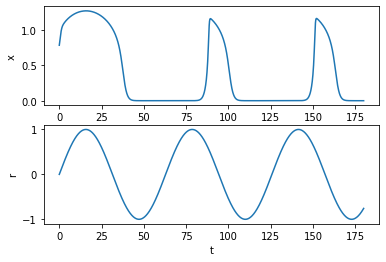

In [8]:
# TASK: investigate hysteresis. Set the bounds on r

import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def flow(x, t):
    
    dxdt = ( (rmax+rmin)/2+(rmax-rmin)*np.sin(romega*t)/2 )*x + x**3 - x**5
    
    return dxdt

# user to select initial value x0 here
x0 = np.pi/4
# user to select r bounds here
rmax = 1
rmin = -1
# user to select r frequency here
romega = 0.1

t = np.arange(0,180,0.1)
r = (rmax+rmin)/2+(rmax-rmin)*np.sin(romega*t)/2

x = odeint(flow, x0, t)

plt.subplot(2,1,1)
plt.plot(t, x)
plt.xlabel('t')
plt.ylabel('x')

plt.subplot(2,1,2)
plt.plot(t, r)
plt.xlabel('t')
plt.ylabel('r')



#### More on terminology...

- The “Supercritical pitchfork” is sometimes called a “forward bifurcation” and is closely related to a continuous or second-order phase transition in statistical mechanics.

- The “Subcritical pitchfork” is sometimes called an “inverted” or “backward” bifurcation, and is related to discontinuous or first-order phase transitions.

- In engineering, “supercritical” bifurcations are sometimes called “soft” or “safe”, while “subcritical” are “hard” or “dangerous”!

### Subcritical pitchfork bifurcation in the real world?

$\bullet$ Insect Outbreaks and Catastrophes

Ludwig (1978) proposed the following model for the budworm population dynamics

$$ \dot{N} = RN\left[1 - \frac{N}{K}\right] - p(N) $$

$$ p(N) = \frac{BN^2}{A^2 + N^2} $$

$ $where $A, B$ are constants ($> 0$), $N(t)$ is the budworm population, $R$ is the growth rate, $K$ is carrying capacity (recall lecture 2) and $p(N)$ represents the death rate due to predators (e.g. birds).

Rewrite the equation in dimensionless form:

$$ \frac{\mathrm{d}x}{\mathrm{d}\tau} = r x\left[1 - \frac{x}{k}\right] -  \frac{x^2}{1 + x^2} $$

where $ x = N/A $, $ \tau = Bt/A$, $r = RA/B$, $k = K/A$.





Fixed points, $x^*$?

By inspection, FP1: $x^* = 0$

FP2:

$$  \left[1 - \frac{x^*}{k}\right] =  \frac{x^{*2}}{1 + x^{*2}} $$

We can solve this equation graphically for different values of $r, k$

<div>
<img src="figures/Fig3_6_1a.png" width="500"/>
<img src="figures/Fig3_6_1b.png" width="400"/>  
</div>

i.e. two fixed points, $b$ and $c$, coalesce as we decrease $r$ while $a$ and $b$ coalesce as we increase $r$.

### Stability?

Can be deduced graphically:

<div>
<img src="figures/Fig3_6_2.png" width="500"/>
</div>

Here the phase portrait is shown for control parameter values which give rise to three FPs in addition to $x^* = 0$. The initial condition, $x_0$, determines the fate of the system.

An outbreak only occurs if $x_0 > b$, thus $b$ represents a threshold for the system.

However, an outbreak can be triggered by a saddle node bifurcation: if $r$ and $k$ vary such that the FP at $a$ disappears, the system will jump to outbreak level $c$.

Moreover the system displays *hysteresis*. Restoring the control parameters to their values before the bifurcation will not return the population to its original level.





### Bifurcation curves?

A *bifurcation curve* maps out the points in parameter space at which a bifurcation occurs.

The required solution satisfies both

$$  r \left(1 - \frac{x}{k}\right) =  \frac{x}{1 + x^{2}} $$

and

$$  \frac{\mathrm{d}}{\mathrm{d}x}\left[r\left(1 - \frac{x}{k}\right)\right] =  \frac{\mathrm{d}}{\mathrm{d}x}\left[\frac{x}{1 + x^{2}}\right] $$

These simultaneous equations can be solved to give $k(x)$ and $r(x)$, which can be mapped out analystically in $(k,r)$ space for diffrerent values of $x$ to give the required solution.




<div>
<img src="figures/Fig3_6_3.png" width="550"/>
</div>


$ $We can plot the fixed points $x^*$ as a function of the system parameters to yield a 3-dimensional surface called a cusp catastrophe surface...

<div>
<img src="figures/Fig3_6_4.png" width="550"/>
</div>

$\bullet$ The cusp catastrophe surface folds over on itself in certain places.

$\bullet$ The projection of these folds onto the (k,r) plane yields the bifurcation curves

$\bullet$ The term “catastrophe” is motivated by the fact that, as parameters change, the state of the system can be carried over the edge of the upper surface, after which it drops discontinuously to the lower surface.

$\bullet$ This jump could be truly catastrophic for the equilibrium e.g. of a bridge or a building!